# Customer Churn Prediction — Telco
### Custom Logistic Regression (NumPy, from scratch) benchmarked against scikit-learn

**Business problem.** Acquiring a customer costs several times more than retaining one. If we can identify *who is likely to leave before they leave*, the retention team can target offers where they matter.

**Objective.** Build a production-style churn classifier and demonstrate it end-to-end:

| Stage | What is done |
|---|---|
| 1. Data audit & cleaning | types, blanks, duplicates, target encoding |
| 2. EDA | target balance, distributions, churn drivers, statistical tests, correlations |
| 3. Feature engineering | tenure buckets, add-on counts, contract × payment interactions, etc. |
| 4. **Model from scratch** | sigmoid, log-loss (cross-entropy), batch gradient descent, L2 regularisation, class weights |
| 5. Class imbalance | class weights vs random oversampling vs threshold moving (compared with CV) |
| 6. Rigorous evaluation | 5-fold CV for all tuning, untouched 20 % test set, bootstrap confidence intervals |
| 7. Benchmark | scikit-learn LR, Random Forest, Gradient Boosting |
| 8. Business impact | gains/lift, expected campaign profit |
| 9. Export | model weights → JSON for the React dashboard |

> **Evaluation protocol.** The test set is split off first and touched exactly once at the end. Scaling statistics, hyper-parameters and the decision threshold are all chosen using training data only (cross-validation).

In [ ]:
import warnings, json, os
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, precision_score, recall_score
from sklearn.calibration import calibration_curve

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
BLUE, RED = "#4C78A8", "#E4572E"
DATA_PATH = "../data/Telco-Customer-Churn.csv"

## 1. Data audit & cleaning

In [ ]:
raw = pd.read_csv(DATA_PATH)
print("Shape:", raw.shape)
display(raw.head())
audit = pd.DataFrame({"dtype": raw.dtypes.astype(str), "missing": raw.isna().sum(), "n_unique": raw.nunique()})
display(audit.T)
print("Duplicate rows:", raw.duplicated().sum(), "| duplicate customer IDs:", raw.customerID.duplicated().sum())

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
dtype,str,str,int64,str,str,int64,str,str,str,str,...,str,str,str,str,str,str,str,float64,str,str
missing,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
n_unique,7043,2,2,2,2,73,2,3,3,3,...,3,3,3,3,3,2,4,1585,6531,2


Duplicate rows: 0 | duplicate customer IDs: 0


In [ ]:
df = raw.copy()

# TotalCharges is stored as text because 11 rows contain a blank string.
blank = df["TotalCharges"].str.strip() == ""
print(f"Blank TotalCharges rows: {blank.sum()}  | all of them are brand-new customers (tenure == 0): {(df.loc[blank,'tenure']==0).all()}")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce").fillna(0.0)   # nothing billed yet -> 0

df["Churn"] = (df["Churn"] == "Yes").astype(int)
print(f"\nClean shape: {df.shape} | missing values left: {int(df.isna().sum().sum())} | churn rate: {df.Churn.mean():.2%}")

Blank TotalCharges rows: 11  | all of them are brand-new customers (tenure == 0): True

Clean shape: (7043, 21) | missing values left: 0 | churn rate: 26.54%


## 2. Exploratory data analysis

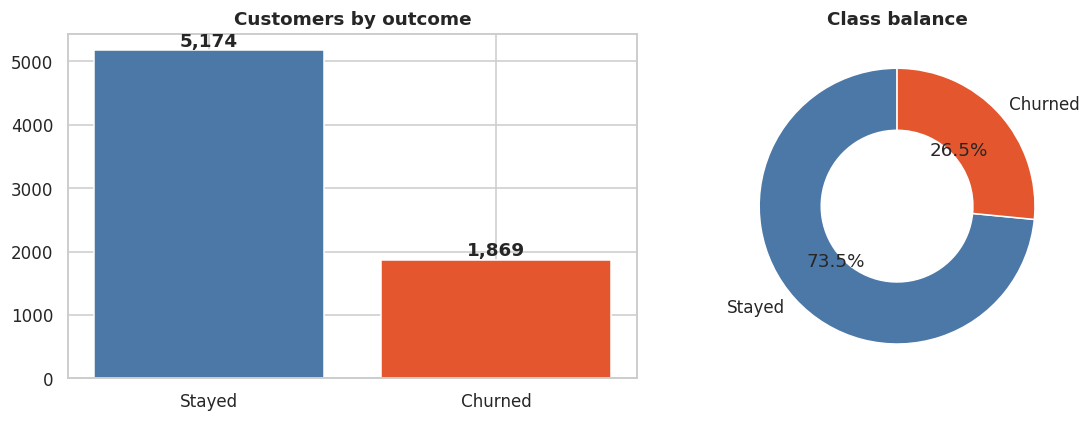

Imbalance ratio ≈ 2.77 : 1  -> accuracy alone is a misleading metric here (predicting 'Stayed' for everyone already scores 73.5 %).


In [ ]:
base = df.Churn.mean() * 100
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
counts = df.Churn.map({0: "Stayed", 1: "Churned"}).value_counts()
ax[0].bar(counts.index, counts.values, color=[BLUE, RED]); ax[0].set_title("Customers by outcome")
for i, v in enumerate(counts.values): ax[0].text(i, v + 60, f"{v:,}", ha="center", fontweight="bold")
ax[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", colors=[BLUE, RED], startangle=90, wedgeprops=dict(width=.45))
ax[1].set_title("Class balance"); plt.tight_layout(); plt.show()
print(f"Imbalance ratio ≈ {counts['Stayed']/counts['Churned']:.2f} : 1  -> accuracy alone is a misleading metric here (predicting 'Stayed' for everyone already scores {100-base:.1f} %).")

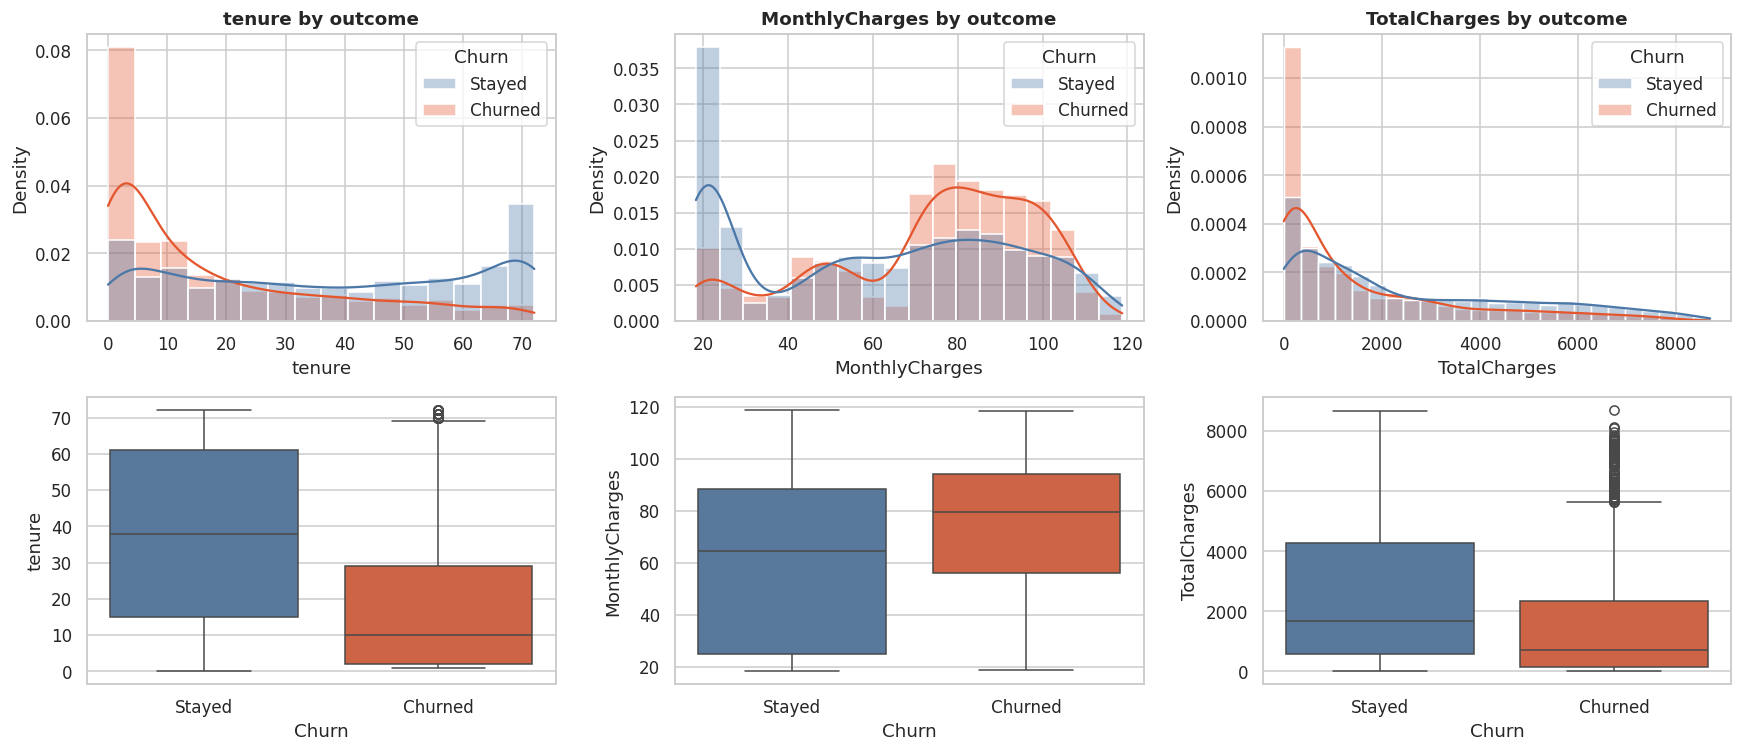

,Churned,Stayed
median,,
tenure,10.0,38.0
MonthlyCharges,79.6,64.4
TotalCharges,703.6,1679.5


In [ ]:
nums = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
lab = df.Churn.map({0: "Stayed", 1: "Churned"})
for j, c in enumerate(nums):
    sns.histplot(data=df, x=c, hue=lab, kde=True, stat="density", common_norm=False, palette=[BLUE, RED], ax=axes[0, j], alpha=.35)
    axes[0, j].set_title(f"{c} by outcome")
    sns.boxplot(data=df, x=lab, y=c, palette=[BLUE, RED], ax=axes[1, j], order=["Stayed", "Churned"])
plt.tight_layout(); plt.show()
display(df.groupby(lab)[nums].median().round(1).rename_axis(None).T.rename_axis("median"))

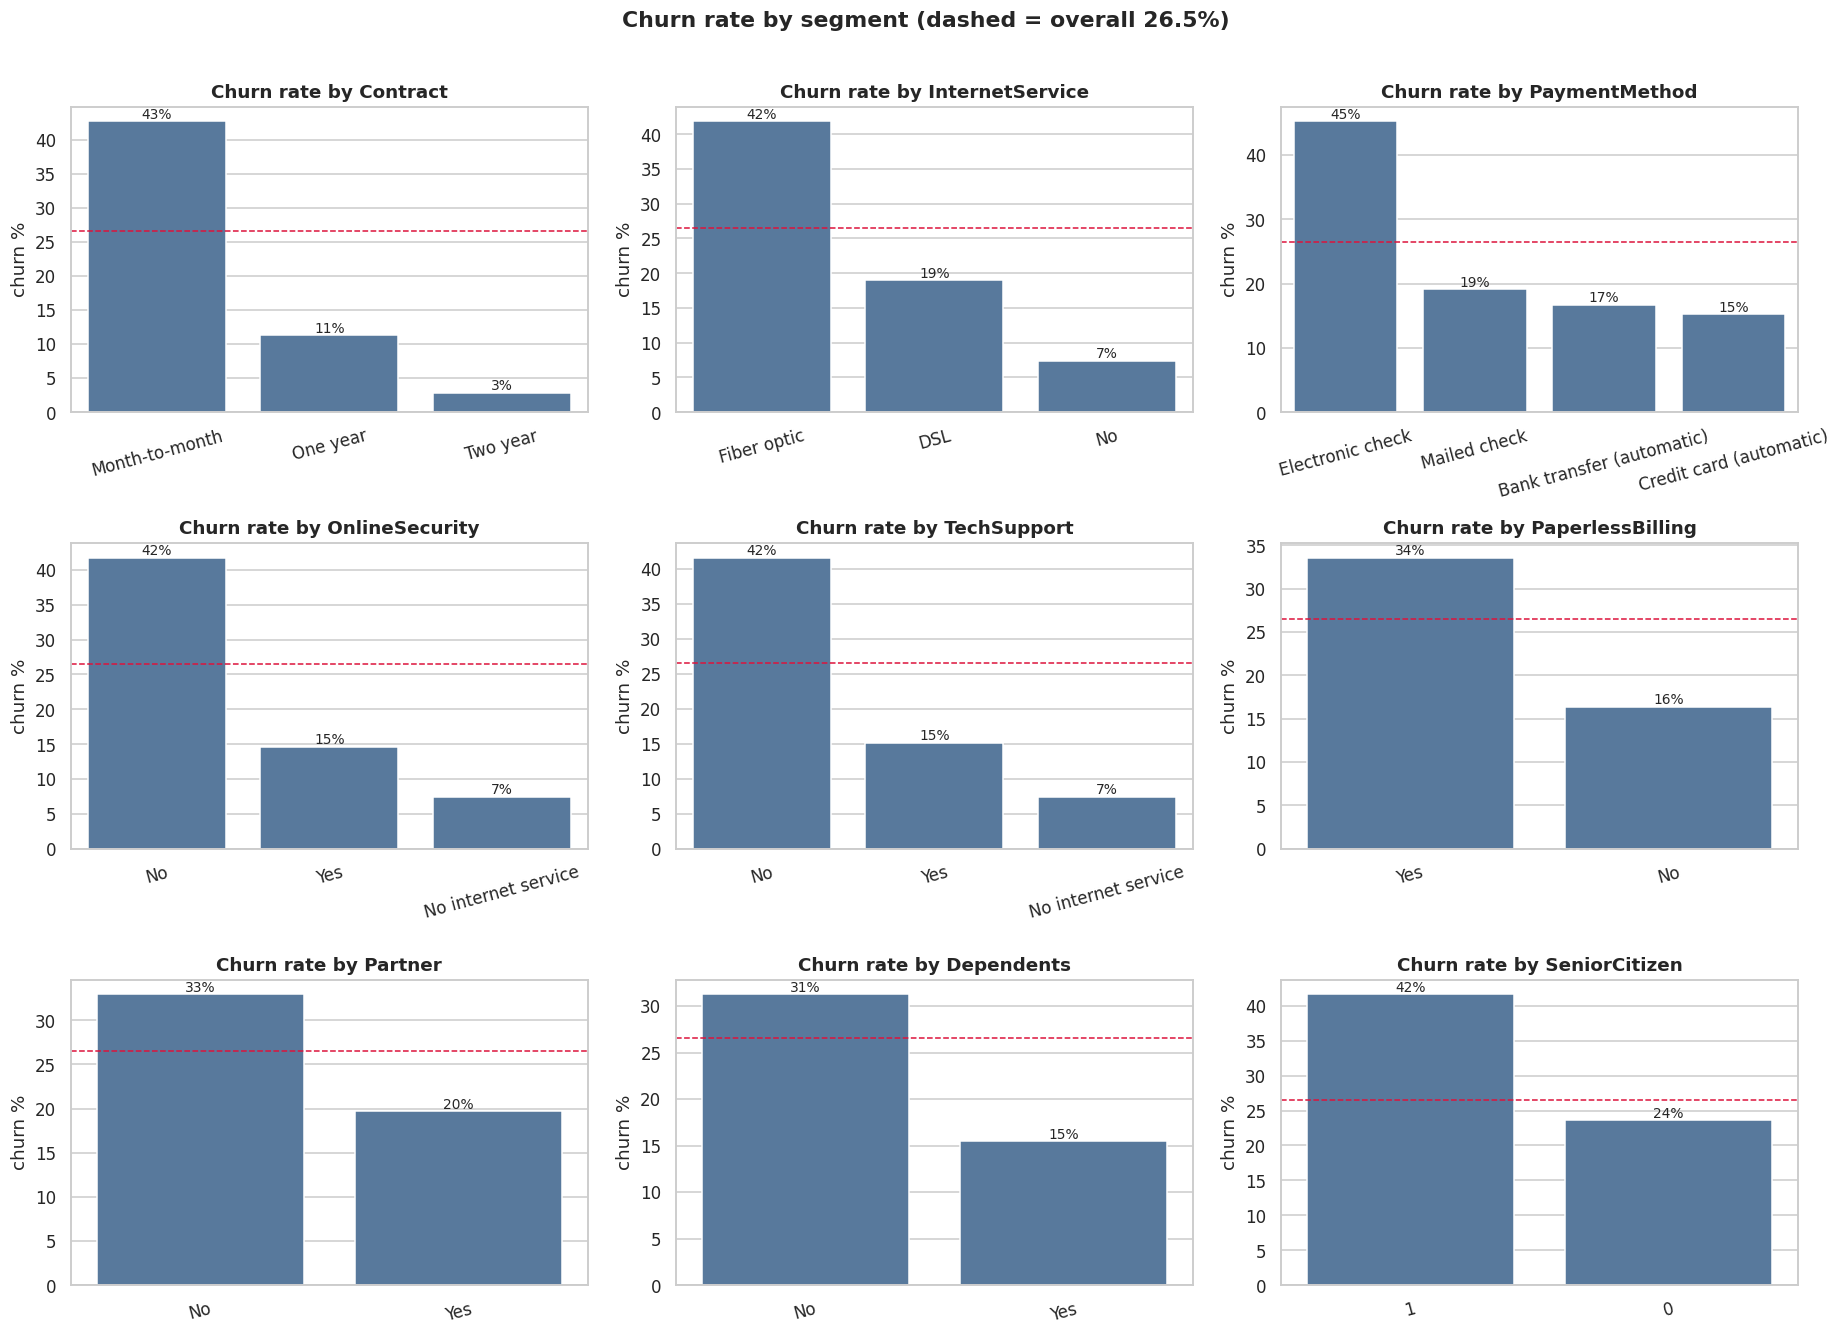

In [ ]:
cat_eda = ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport", "PaperlessBilling", "Partner", "Dependents", "SeniorCitizen"]
fig, axes = plt.subplots(3, 3, figsize=(17, 12))
for ax, c in zip(axes.ravel(), cat_eda):
    r = df.groupby(c).Churn.mean().mul(100).sort_values(ascending=False)
    sns.barplot(x=r.index.astype(str), y=r.values, ax=ax, color=BLUE)
    ax.axhline(base, ls="--", color="crimson", lw=1); ax.set_title(f"Churn rate by {c}"); ax.set_ylabel("churn %"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
    for p in ax.patches: ax.annotate(f"{p.get_height():.0f}%", (p.get_x()+p.get_width()/2, p.get_height()), ha="center", va="bottom", fontsize=9)
plt.suptitle(f"Churn rate by segment (dashed = overall {base:.1f}%)", y=1.01, fontweight="bold"); plt.tight_layout(); plt.show()

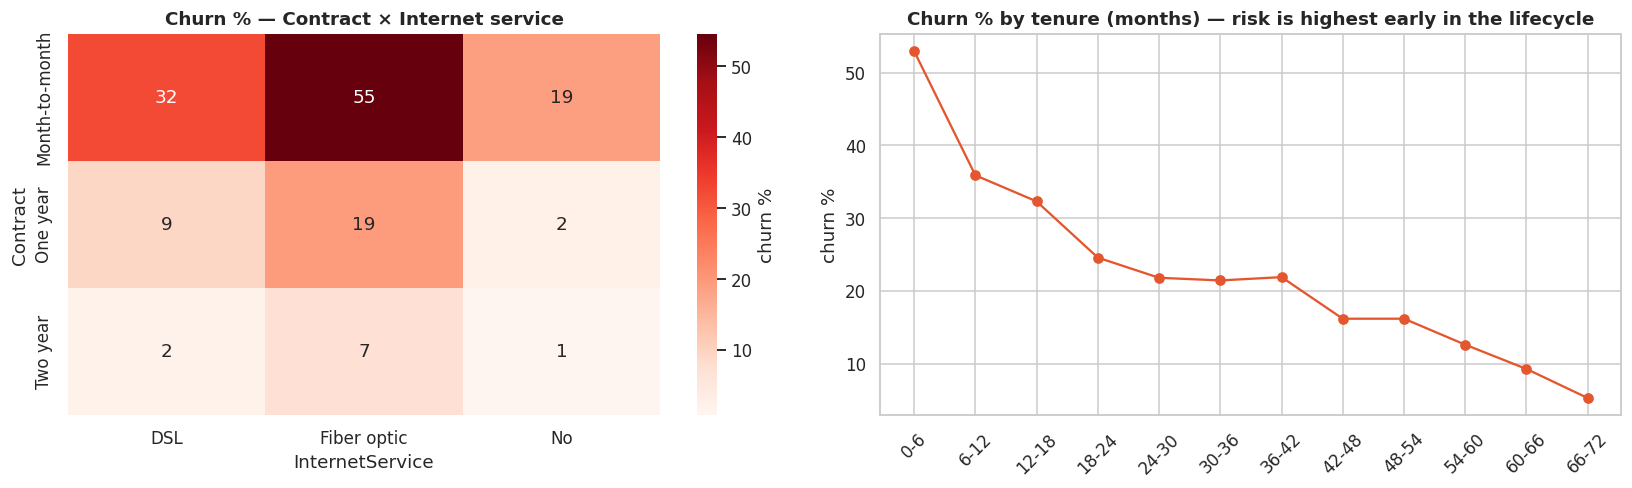

In [ ]:
# Contract x Internet service heat-map + tenure lifecycle curve
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
pv = df.pivot_table(index="Contract", columns="InternetService", values="Churn", aggfunc="mean").mul(100)
sns.heatmap(pv, annot=True, fmt=".0f", cmap="Reds", ax=ax[0], cbar_kws={"label": "churn %"}); ax[0].set_title("Churn % — Contract × Internet service")
t = df.assign(bucket=pd.cut(df.tenure, list(range(0, 78, 6)), include_lowest=True)).groupby("bucket").Churn.mean().mul(100)
ax[1].plot(range(len(t)), t.values, marker="o", color=RED); ax[1].set_xticks(range(len(t))); ax[1].set_xticklabels([f"{int(i.left)}-{int(i.right)}" for i in t.index], rotation=45)
ax[1].set_title("Churn % by tenure (months) — risk is highest early in the lifecycle"); ax[1].set_ylabel("churn %")
plt.tight_layout(); plt.show()

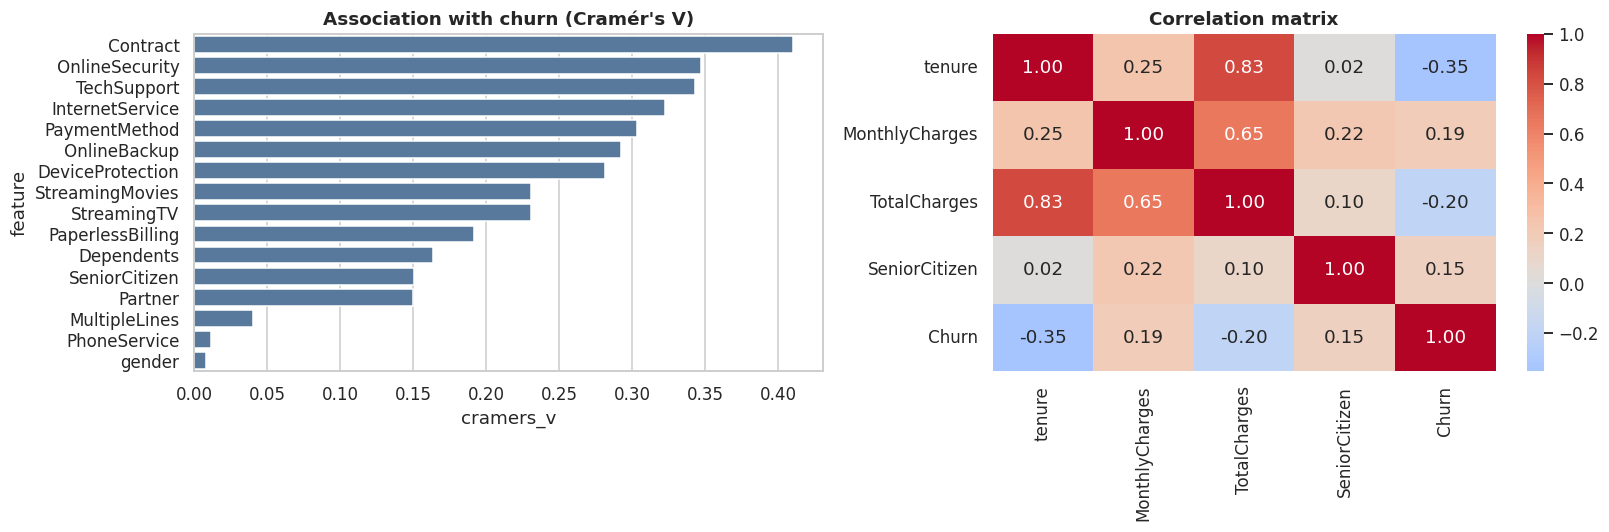

Not significant at 5% (candidates to drop): ['PhoneService', 'gender']
Mann-Whitney tenure: p = 2.42e-208
Mann-Whitney MonthlyCharges: p = 3.31e-54
corr(TotalCharges, tenure x MonthlyCharges) = 1.000  -> TotalCharges is almost fully redundant


In [ ]:
# Which variables are statistically associated with churn?  chi-square + Cramér's V (categorical), Mann-Whitney U (numeric)
rows = []
for c in [c for c in df.columns if c not in ["customerID", "Churn", "TotalCharges", "tenure", "MonthlyCharges"]]:
    ct = pd.crosstab(df[c], df.Churn); chi2, p, _, _ = stats.chi2_contingency(ct)
    rows.append((c, np.sqrt(chi2 / (len(df) * (min(ct.shape) - 1))), p))
assoc = pd.DataFrame(rows, columns=["feature", "cramers_v", "p_value"]).sort_values("cramers_v", ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=assoc, y="feature", x="cramers_v", color=BLUE, ax=ax[0]); ax[0].set_title("Association with churn (Cramér's V)")
corr = df[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1]); ax[1].set_title("Correlation matrix")
plt.tight_layout(); plt.show()
print("Not significant at 5% (candidates to drop):", assoc.loc[assoc.p_value > .05, "feature"].tolist())
for c in ["tenure", "MonthlyCharges"]:
    u, p = stats.mannwhitneyu(df.loc[df.Churn == 1, c], df.loc[df.Churn == 0, c]); print(f"Mann-Whitney {c}: p = {p:.2e}")
print(f"corr(TotalCharges, tenure x MonthlyCharges) = {np.corrcoef(df.TotalCharges, df.tenure*df.MonthlyCharges)[0,1]:.3f}  -> TotalCharges is almost fully redundant")

### EDA takeaways
* **Contract type is the strongest lever** – month-to-month customers churn at ≈ 43 %, versus ≈ 11 % (one-year) and ≈ 3 % (two-year).
* **Fiber-optic customers (≈ 42 %) and electronic-check payers (≈ 45 %) churn far more** than average; month-to-month + fiber + e-check customers in their first year churn at ≈ 71 %.
* **New customers are the most fragile** – churn falls steadily with tenure.
* Customers **without Online Security / Tech Support** churn more; those with several add-ons are stickier.
* `gender` shows no significant association with churn (and is a sensitive attribute) → **excluded from the model**. `PhoneService` is also not significant; it is kept only because it is harmless under L2 regularisation.
* `TotalCharges` ≈ `tenure × MonthlyCharges` (r ≈ 1.0 with that product) → **excluded** to avoid multicollinearity; the ablation in §6 confirms this costs nothing in performance.

## 3. Feature engineering

In [ ]:
ADDONS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]
CAT_COLS = ["Partner", "Dependents", "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "tenure_bin"]
NUM_COLS = ["SeniorCitizen", "tenure", "MonthlyCharges", "n_addons", "tenure_log", "autopay", "mtm_fiber", "mtm_echeck", "family", "no_support_internet"]

def engineer_features(d):
    """Raw Telco frame -> model matrix. Uses ONLY information available at prediction time (no target leakage)."""
    d = d.copy()
    for c in ["MultipleLines"] + ADDONS:                                   # 'No internet/phone service' is just 'No'
        d[c] = d[c].replace({"No internet service": "No", "No phone service": "No"})
    d["n_addons"]  = (d[ADDONS] == "Yes").sum(axis=1)                       # number of add-on services
    d["tenure_log"] = np.log1p(d["tenure"])                                 # diminishing effect of tenure
    d["tenure_bin"] = pd.cut(d["tenure"], [-1, 6, 12, 24, 48, 1000], labels=["0-6", "7-12", "13-24", "25-48", "49+"]).astype(str)
    d["autopay"]    = d["PaymentMethod"].str.contains("automatic").astype(int)
    d["mtm_fiber"]  = ((d["Contract"] == "Month-to-month") & (d["InternetService"] == "Fiber optic")).astype(int)
    d["mtm_echeck"] = ((d["Contract"] == "Month-to-month") & (d["PaymentMethod"] == "Electronic check")).astype(int)
    d["family"]     = ((d["Partner"] == "Yes") | (d["Dependents"] == "Yes")).astype(int)
    d["no_support_internet"] = ((d["InternetService"] != "No") & (d["OnlineSecurity"] == "No") & (d["TechSupport"] == "No")).astype(int)
    return pd.get_dummies(d[NUM_COLS + CAT_COLS], columns=CAT_COLS, drop_first=True, dtype=float)

X_all, y_all = engineer_features(df), df["Churn"].values
print("Model matrix:", X_all.shape)

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.20, stratify=y_all, random_state=SEED)
Xtr, Xte = X_train.values, X_test.values
print(f"train {Xtr.shape} (churn {y_train.mean():.2%}) | test {Xte.shape} (churn {y_test.mean():.2%})   <- test set is now locked away")

Model matrix: (7043, 32)
train (5634, 32) (churn 26.54%) | test (1409, 32) (churn 26.54%)   <- test set is now locked away


## 4. Logistic regression from scratch (NumPy only)

For a customer with standardised features $x$, the model predicts

$$\hat p = \sigma(w^\top x + b),\qquad \sigma(z)=\frac{1}{1+e^{-z}}$$

and minimises the class-weighted, L2-regularised **log-loss (cross-entropy)**

$$J(w,b)= -\frac{1}{\sum_i s_i}\sum_i s_i\Big[y_i\log\hat p_i+(1-y_i)\log(1-\hat p_i)\Big]+\frac{\lambda}{2}\lVert w\rVert^2 ,$$

with sample weights $s_i$ (all 1, or "balanced" $s_i = n/(2 n_{c_i})$ to counter class imbalance). Its gradient is simply

$$\nabla_w J=\frac{1}{\sum s_i}X^\top\big[s\odot(\hat p-y)\big]+\lambda w,\qquad \nabla_b J=\frac{1}{\sum s_i}\sum_i s_i(\hat p_i-y_i)$$

and **batch gradient descent** updates $w\leftarrow w-\eta\nabla_wJ$. Evaluation metrics (accuracy, precision, recall, F1, ROC-AUC) are also implemented by hand and cross-checked against scikit-learn.

In [ ]:
_trapz = getattr(np, "trapezoid", None) or np.trapz

def sigmoid(z):
    """Numerically stable sigmoid (never exponentiates a large positive number)."""
    z = np.asarray(z, dtype=float); out = np.empty_like(z); pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos])); e = np.exp(z[~pos]); out[~pos] = e / (1.0 + e)
    return out

def log_loss_scratch(y, p, sw=None, eps=1e-12):
    p = np.clip(p, eps, 1 - eps); sw = np.ones_like(y, dtype=float) if sw is None else sw
    return -(sw * (y * np.log(p) + (1 - y) * np.log(1 - p))).sum() / sw.sum()

class LogisticRegressionScratch:
    def __init__(self, lr=0.5, n_iter=5000, l2=1e-2, class_weight=None, tol=1e-10):
        self.lr, self.n_iter, self.l2, self.class_weight, self.tol = lr, n_iter, l2, class_weight, tol

    def _sample_weights(self, y):
        if self.class_weight == "balanced":
            n, n1 = len(y), y.sum()
            return np.where(y == 1, n / (2 * n1), n / (2 * (n - n1)))
        return np.ones(len(y))

    def fit(self, X, y):
        sw = self._sample_weights(y); s = sw.sum()
        w, b, hist = np.zeros(X.shape[1]), 0.0, []
        for it in range(self.n_iter):
            p = sigmoid(X @ w + b)
            r = sw * (p - y)
            gw, gb = X.T @ r / s + self.l2 * w, r.sum() / s              # gradients
            hist.append(log_loss_scratch(y, p, sw) + 0.5 * self.l2 * (w @ w))
            w, b = w - self.lr * gw, b - self.lr * gb                     # gradient-descent step
            if it > 0 and abs(hist[-2] - hist[-1]) < self.tol: break
        self.w_, self.b_, self.loss_history_ = w, b, hist
        return self

    def predict_proba(self, X): return sigmoid(X @ self.w_ + self.b_)
    def predict(self, X, thr=0.5): return (self.predict_proba(X) >= thr).astype(int)

# ---------- metrics, all from scratch ----------
def metrics_at(y, p, thr=0.5):
    yh = (p >= thr).astype(int)
    tp = int(((y == 1) & (yh == 1)).sum()); tn = int(((y == 0) & (yh == 0)).sum())
    fp = int(((y == 0) & (yh == 1)).sum()); fn = int(((y == 1) & (yh == 0)).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0; rec = tp / (tp + fn) if tp + fn else 0.0
    return dict(accuracy=(tp + tn) / len(y), precision=prec, recall=rec,
                f1=2 * prec * rec / (prec + rec) if prec + rec else 0.0, tn=tn, fp=fp, fn=fn, tp=tp)

def roc_curve_scratch(y, s):
    order = np.argsort(-s, kind="mergesort"); ys, ss = y[order], s[order]
    idx = np.r_[np.where(np.diff(ss))[0], len(ys) - 1]
    tps = np.cumsum(ys)[idx]; fps = 1 + idx - tps
    return np.r_[0, fps / fps[-1]], np.r_[0, tps / tps[-1]]

def roc_auc_scratch(y, s):
    fpr, tpr = roc_curve_scratch(y, s); return float(_trapz(tpr, fpr))

def standardize_fit(X):
    mu, sd = X.mean(0), X.std(0); sd[sd == 0] = 1.0; return mu, sd

### 4.1 Verification — does my implementation match scikit-learn?

Stopped after 1401 iterations, final loss 0.411882
max |w_mine - w_sklearn| = 2.37e-05   |b diff| = 5.52e-10
max |p_mine - p_sklearn| on test = 3.20e-06
Hand-written accuracy / precision / recall / F1 / ROC-AUC match scikit-learn exactly ✔


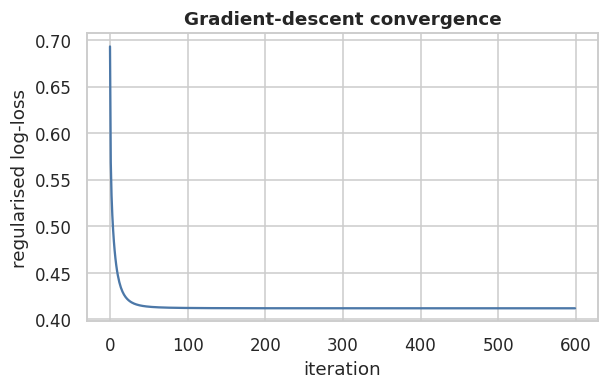

In [ ]:
mu, sd = standardize_fit(Xtr); Ztr, Zte = (Xtr - mu) / sd, (Xte - mu) / sd

# scikit-learn minimises C*sum(loss) + 0.5||w||^2  <=>  mean(loss) + (1/(2*C*n))||w||^2, so lambda = 1/(C*n)
lam = 1e-2
mine = LogisticRegressionScratch(lr=0.5, n_iter=20000, l2=lam, tol=1e-13).fit(Ztr, y_train)
skl  = LogisticRegression(C=1 / (lam * len(y_train)), tol=1e-12, max_iter=10000).fit(Ztr, y_train)

print(f"Stopped after {len(mine.loss_history_)} iterations, final loss {mine.loss_history_[-1]:.6f}")
print(f"max |w_mine - w_sklearn| = {np.abs(mine.w_ - skl.coef_[0]).max():.2e}   |b diff| = {abs(mine.b_ - skl.intercept_[0]):.2e}")
p_m, p_s = mine.predict_proba(Zte), skl.predict_proba(Zte)[:, 1]
print(f"max |p_mine - p_sklearn| on test = {np.abs(p_m - p_s).max():.2e}")
m = metrics_at(y_test, p_m)
assert abs(m["accuracy"] - accuracy_score(y_test, p_m >= .5)) < 1e-12 and abs(m["f1"] - f1_score(y_test, p_m >= .5)) < 1e-12
assert abs(m["precision"] - precision_score(y_test, p_m >= .5)) < 1e-12 and abs(m["recall"] - recall_score(y_test, p_m >= .5)) < 1e-12
assert abs(roc_auc_scratch(y_test, p_m) - roc_auc_score(y_test, p_m)) < 1e-12
print("Hand-written accuracy / precision / recall / F1 / ROC-AUC match scikit-learn exactly ✔")

fig, ax = plt.subplots(figsize=(6, 3.4)); ax.plot(mine.loss_history_[:600], color=BLUE)
ax.set(title="Gradient-descent convergence", xlabel="iteration", ylabel="regularised log-loss"); plt.show()

## 5. Class imbalance (≈ 27 % churners)
Three standard remedies are compared with **5-fold stratified CV on the training set only**. Oversampling and scaling are applied *inside* each fold to avoid leakage.

1. **Nothing** (baseline) 2. **Class weights** ("balanced") 3. **Random oversampling** of the minority class 

A weighted/oversampled model sees a 50/50 world, so its probabilities are inflated. Because the shift is a pure change of prior, it can be undone exactly by adding $\log\frac{\pi}{1-\pi}$ to the logit (`prior_correct`) – this gives *calibrated* probabilities, which matters for the dashboard and for business decisions.

In [ ]:
def oversample(X, y, rng):
    i0, i1 = np.where(y == 0)[0], np.where(y == 1)[0]
    extra = rng.choice(i1, len(i0) - len(i1), replace=True)
    keep = np.r_[np.arange(len(y)), extra]; return X[keep], y[keep]

def prior_correct(p, pi, fitted_prior=0.5):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return sigmoid(np.log(p / (1 - p)) + np.log(pi / (1 - pi)) - np.log(fitted_prior / (1 - fitted_prior)))

def oof_predict(X, y, params, resample=False, n_splits=5, seed=SEED):
    """Out-of-fold probabilities. Scaler is re-fit inside every fold."""
    oof, rng = np.zeros(len(y)), np.random.default_rng(seed)
    for tr, va in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(X, y):
        m_, s_ = standardize_fit(X[tr]); A, B, ya = (X[tr] - m_) / s_, (X[va] - m_) / s_, y[tr]
        if resample: A, ya = oversample(A, ya, rng)
        oof[va] = LogisticRegressionScratch(**params).fit(A, ya).predict_proba(B)
    return oof

base_p = dict(lr=0.5, n_iter=3000, l2=1e-2)
pi = y_train.mean()
oof = {"No handling": oof_predict(Xtr, y_train, base_p),
       "Class weights": oof_predict(Xtr, y_train, {**base_p, "class_weight": "balanced"}),
       "Oversampling": oof_predict(Xtr, y_train, base_p, resample=True)}
rows = []
for k, p in oof.items():
    r = metrics_at(y_train, p, 0.5); rows.append(dict(strategy=k, threshold=0.5, accuracy=r["accuracy"], precision=r["precision"], recall=r["recall"], f1=r["f1"], roc_auc=roc_auc_scratch(y_train, p)))
# threshold moving on the un-weighted model
grid = np.arange(0.05, 0.95, 0.01); best_t = grid[np.argmax([metrics_at(y_train, oof["No handling"], t)["f1"] for t in grid])]
r = metrics_at(y_train, oof["No handling"], best_t)
rows.append(dict(strategy="Threshold moving (F1-tuned)", threshold=best_t, accuracy=r["accuracy"], precision=r["precision"], recall=r["recall"], f1=r["f1"], roc_auc=roc_auc_scratch(y_train, oof["No handling"])))
imb = pd.DataFrame(rows).set_index("strategy"); display(imb.style.format("{:.3f}").background_gradient(cmap="Blues", axis=0))

,threshold,accuracy,precision,recall,f1,roc_auc
strategy,,,,,,
No handling,0.500,0.805,0.670,0.525,0.589,0.849
Class weights,0.500,0.757,0.528,0.790,0.633,0.849
Oversampling,0.500,0.757,0.528,0.789,0.633,0.847
Threshold moving (F1-tuned),0.340,0.788,0.582,0.706,0.638,0.849


**Reading the table:** all strategies have essentially the same ranking quality (ROC-AUC) – they only move the operating point. The un-weighted model has the best accuracy but misses most churners (low recall); class weights / oversampling / threshold-moving trade a few points of accuracy for a large gain in recall and F1, which is what a retention team needs. I use **class weights** (deterministic, no duplicated rows) and then tune the decision threshold explicitly.

## 6. Hyper-parameter tuning & decision threshold (cross-validation only)

,cv_roc_auc,cv_log_loss (calibrated)
l2 (lambda),,
0.000100,0.8485,0.4121
0.001000,0.8486,0.4121
0.003000,0.8486,0.4121
0.010000,0.8486,0.4122
0.030000,0.8484,0.4130
0.100000,0.8471,0.4177


Selected lambda: 0.003


Threshold chosen from out-of-fold predictions -> F1-optimal: 0.340 | accuracy-optimal: 0.510


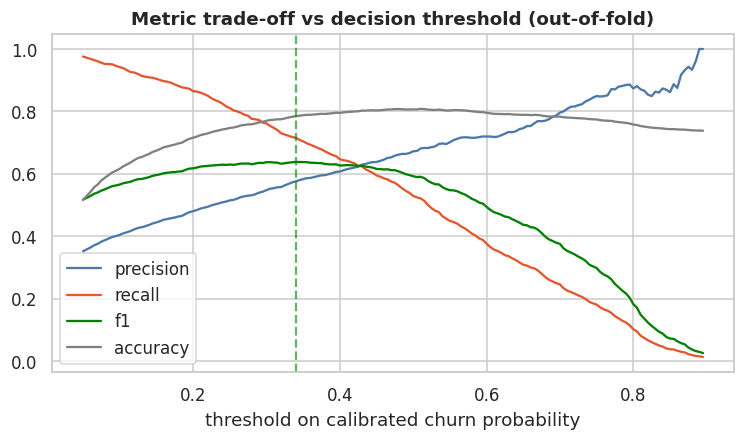

In [ ]:
res = []
for l2 in [1e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]:
    p = oof_predict(Xtr, y_train, {**base_p, "l2": l2, "class_weight": "balanced"})
    res.append((l2, roc_auc_scratch(y_train, p), log_loss_scratch(y_train, prior_correct(p, pi))))
tune = pd.DataFrame(res, columns=["l2 (lambda)", "cv_roc_auc", "cv_log_loss (calibrated)"]).set_index("l2 (lambda)"); display(tune.style.format("{:.4f}"))
best_l2 = tune["cv_log_loss (calibrated)"].idxmin(); print("Selected lambda:", best_l2)

final_p = {**base_p, "l2": best_l2, "class_weight": "balanced"}
oof_cal = prior_correct(oof_predict(Xtr, y_train, final_p), pi)
grid = np.arange(0.05, 0.90, 0.005)
sweep = pd.DataFrame([{"thr": t, **metrics_at(y_train, oof_cal, t)} for t in grid])
thr_f1, thr_acc = float(sweep.loc[sweep.f1.idxmax(), "thr"]), float(sweep.loc[sweep.accuracy.idxmax(), "thr"])
print(f"Threshold chosen from out-of-fold predictions -> F1-optimal: {thr_f1:.3f} | accuracy-optimal: {thr_acc:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
for c, col in [("precision", BLUE), ("recall", RED), ("f1", "green"), ("accuracy", "gray")]: ax.plot(sweep.thr, sweep[c], label=c, color=col)
ax.axvline(thr_f1, ls="--", color="green", alpha=.6); ax.set(title="Metric trade-off vs decision threshold (out-of-fold)", xlabel="threshold on calibrated churn probability"); ax.legend(); plt.show()

In [ ]:
# Ablation (training data only): does re-adding the redundant TotalCharges column help?
tc = df.loc[X_train.index, "TotalCharges"].values.reshape(-1, 1)
p_with = oof_predict(np.c_[Xtr, tc], y_train, final_p)
p_without = oof_predict(Xtr, y_train, final_p)
print(f"CV ROC-AUC without TotalCharges: {roc_auc_scratch(y_train, p_without):.4f} | with TotalCharges: {roc_auc_scratch(y_train, p_with):.4f}  -> no gain, so it stays out")

CV ROC-AUC without TotalCharges: 0.8486 | with TotalCharges: 0.8486  -> no gain, so it stays out


## 7. Final evaluation on the untouched test set

,accuracy,precision,recall,f1,roc_auc
Accuracy-oriented @ 0.51,0.806,0.672,0.521,0.587,0.848
Recall-oriented (F1-tuned) @ 0.34,0.779,0.565,0.735,0.639,0.848


,2.5%,97.5%
accuracy,0.757,0.800
precision,0.519,0.608
recall,0.687,0.777
f1,0.597,0.675
roc_auc,0.827,0.869


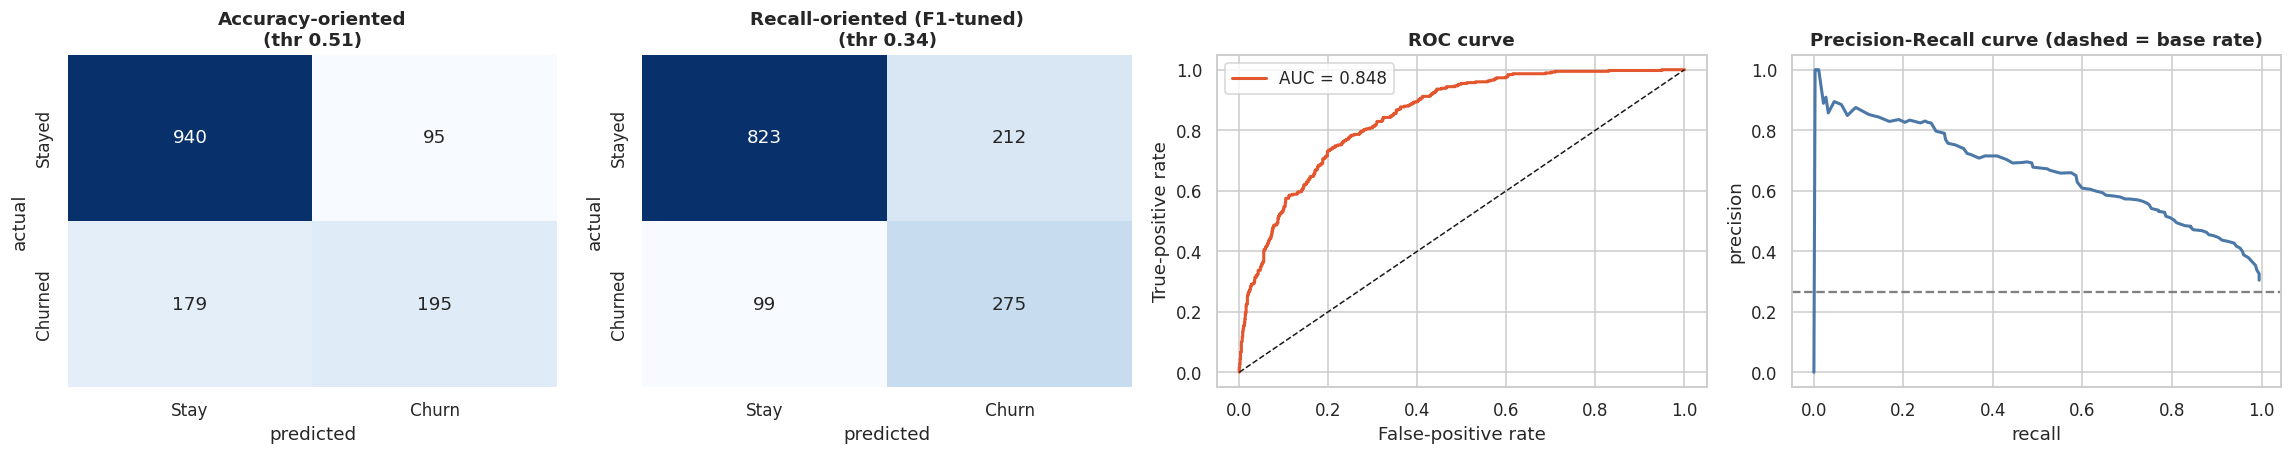

In [ ]:
mu, sd = standardize_fit(Xtr); Ztr, Zte = (Xtr - mu) / sd, (Xte - mu) / sd
final = LogisticRegressionScratch(**final_p).fit(Ztr, y_train)
p_test = prior_correct(final.predict_proba(Zte), pi)                # calibrated churn probability

points = {"Accuracy-oriented": thr_acc, "Recall-oriented (F1-tuned)": thr_f1}
rows = {}
for name, t in points.items():
    r = metrics_at(y_test, p_test, t); rows[f"{name} @ {t:.2f}"] = {**{k: r[k] for k in ["accuracy", "precision", "recall", "f1"]}, "roc_auc": roc_auc_scratch(y_test, p_test)}
res_tbl = pd.DataFrame(rows).T; display(res_tbl.style.format("{:.3f}"))

# Bootstrap 95% CIs (1000 resamples of the test set) at the F1-tuned threshold
rng = np.random.default_rng(SEED); boot = {k: [] for k in ["accuracy", "precision", "recall", "f1", "roc_auc"]}
for _ in range(1000):
    i = rng.integers(0, len(y_test), len(y_test)); r = metrics_at(y_test[i], p_test[i], thr_f1)
    for k in ["accuracy", "precision", "recall", "f1"]: boot[k].append(r[k])
    boot["roc_auc"].append(roc_auc_scratch(y_test[i], p_test[i]))
ci = {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in boot.items()}
display(pd.DataFrame(ci, index=["2.5%", "97.5%"]).T.style.format("{:.3f}").set_caption("Bootstrap 95% confidence intervals (F1-tuned threshold)"))

fig, ax = plt.subplots(1, 4, figsize=(21, 4.3))
for a, (name, t) in zip(ax[:2], points.items()):
    r = metrics_at(y_test, p_test, t); cm = np.array([[r["tn"], r["fp"]], [r["fn"], r["tp"]]])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=a, xticklabels=["Stay", "Churn"], yticklabels=["Stayed", "Churned"]); a.set(title=f"{name}\n(thr {t:.2f})", xlabel="predicted", ylabel="actual")
fpr, tpr = roc_curve_scratch(y_test, p_test); ax[2].plot(fpr, tpr, color=RED, lw=2, label=f"AUC = {roc_auc_scratch(y_test, p_test):.3f}"); ax[2].plot([0, 1], [0, 1], "k--", lw=1); ax[2].set(title="ROC curve", xlabel="False-positive rate", ylabel="True-positive rate"); ax[2].legend()
sw_test = pd.DataFrame([{"thr": t, **metrics_at(y_test, p_test, t)} for t in np.arange(0.02, 0.98, 0.01)])
ax[3].plot(sw_test.recall, sw_test.precision, color=BLUE, lw=2); ax[3].axhline(y_test.mean(), ls="--", color="gray"); ax[3].set(title="Precision-Recall curve (dashed = base rate)", xlabel="recall", ylabel="precision")
plt.tight_layout(); plt.show()

## 8. Benchmark against scikit-learn models

In [ ]:
lam_sk = 1 / (best_l2 * len(y_train))
models = {
    "Scratch LR (no weights)":          (LogisticRegressionScratch(**{**final_p, "class_weight": None}), "scratch"),
    "Scratch LR (balanced)  [mine]":    (final, "scratch_fitted"),
    "sklearn LR (no weights)":          (LogisticRegression(C=lam_sk, max_iter=5000), "sk"),
    "sklearn LR (balanced)":            (LogisticRegression(C=lam_sk, max_iter=5000, class_weight="balanced"), "sk"),
    "Random Forest (balanced, tuned)":  (RandomForestClassifier(500, min_samples_leaf=8, max_features="sqrt", class_weight="balanced_subsample", random_state=SEED, n_jobs=-1), "sk"),
    "Gradient Boosting (balanced)":     (HistGradientBoostingClassifier(max_depth=3, learning_rate=0.05, max_iter=250, l2_regularization=1.0, class_weight="balanced", random_state=SEED), "sk"),
    "Random Forest (unpruned)":         (RandomForestClassifier(500, class_weight="balanced_subsample", random_state=SEED, n_jobs=-1), "sk"),
}
rows = []
for name, (m, kind) in models.items():
    if kind == "scratch": m.fit(Ztr, y_train)
    elif kind == "sk": m.fit(Ztr, y_train)
    pt, ptr = m.predict_proba(Zte), m.predict_proba(Ztr)
    pt, ptr = (pt if kind.startswith("scratch") else pt[:, 1]), (ptr if kind.startswith("scratch") else ptr[:, 1])
    r = metrics_at(y_test, pt, 0.5)
    rows.append(dict(model=name, accuracy=r["accuracy"], precision=r["precision"], recall=r["recall"], f1=r["f1"], roc_auc=roc_auc_scratch(y_test, pt), train_accuracy=metrics_at(y_train, ptr, 0.5)["accuracy"]))
bench = pd.DataFrame(rows).set_index("model"); display(bench.style.format("{:.3f}").background_gradient(cmap="Greens", subset=["roc_auc", "f1"]))
print("All rows: default 0.5 threshold, test set.  train_accuracy >> accuracy signals over-fitting (see the unpruned forest).")

,accuracy,precision,recall,f1,roc_auc,train_accuracy
model,,,,,,
Scratch LR (no weights),0.803,0.664,0.524,0.586,0.848,0.811
Scratch LR (balanced) [mine],0.746,0.514,0.791,0.623,0.848,0.760
sklearn LR (no weights),0.803,0.664,0.524,0.586,0.848,0.811
sklearn LR (balanced),0.745,0.513,0.791,0.623,0.848,0.760
"Random Forest (balanced, tuned)",0.767,0.544,0.757,0.633,0.843,0.810
Gradient Boosting (balanced),0.752,0.522,0.783,0.627,0.840,0.776
Random Forest (unpruned),0.776,0.600,0.473,0.529,0.818,0.997


All rows: default 0.5 threshold, test set.  train_accuracy >> accuracy signals over-fitting (see the unpruned forest).


**Interpretation.** A hand-written logistic regression is statistically indistinguishable from scikit-learn's, and *more complex models (random forest, gradient boosting) do not beat it* — ROC-AUC sits between 0.82 and 0.85 for every model family, and the simple model is at the top. This is the signature of a **data-limited problem**: the remaining error is customer behaviour that simply isn't recorded in these 19 columns (competitor offers, service outages, life events…), not a modelling deficiency. Note the unpruned forest reaches ~99.7 % accuracy **on the training set** while scoring ~78 % on the test set (and a worse ROC-AUC) – exactly the trap that produces "98 % accuracy" headlines.

## 9. Model interpretation

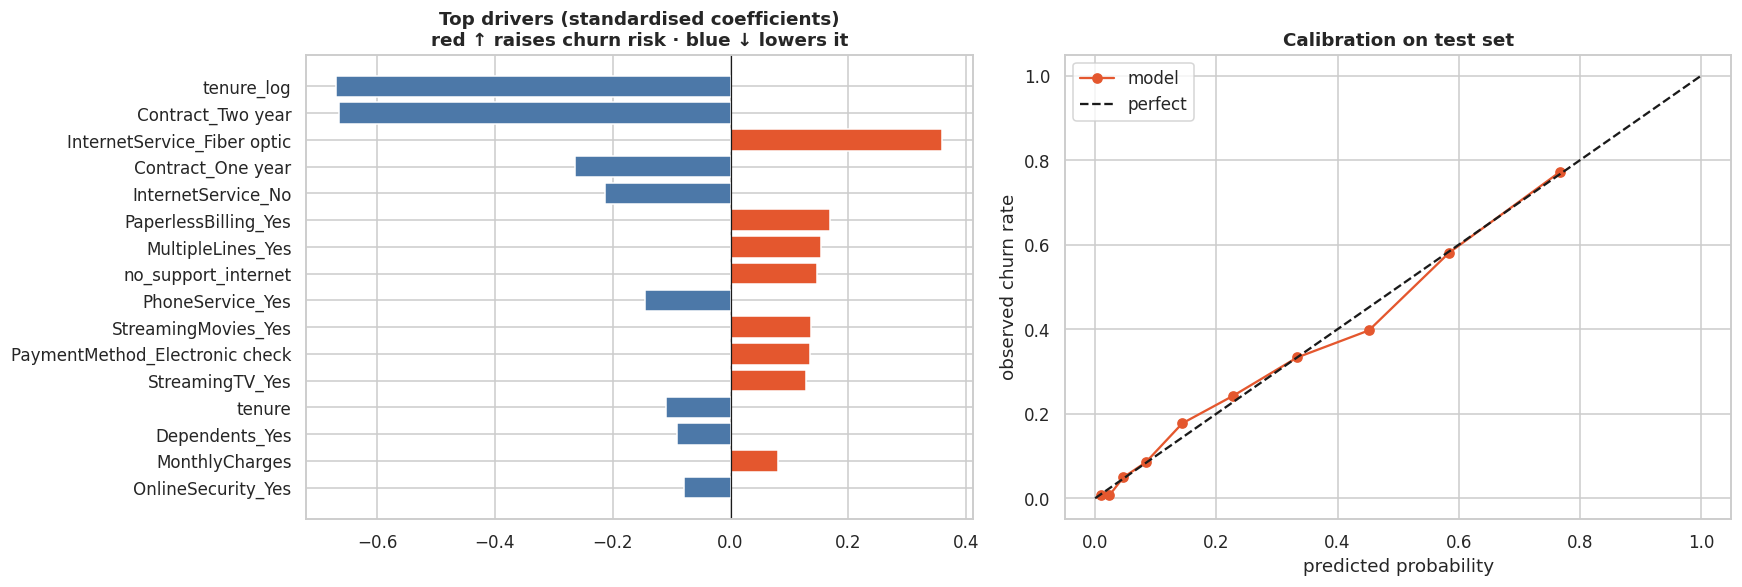

In [ ]:
coef = pd.Series(final.w_, index=X_all.columns).sort_values(key=np.abs, ascending=False).head(16)
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
ax[0].barh(coef.index[::-1], coef.values[::-1], color=[RED if v > 0 else BLUE for v in coef.values[::-1]]); ax[0].axvline(0, color="k", lw=.8)
ax[0].set_title("Top drivers (standardised coefficients)\nred ↑ raises churn risk · blue ↓ lowers it")
frac, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
ax[1].plot(mean_pred, frac, "o-", color=RED, label="model"); ax[1].plot([0, 1], [0, 1], "k--", label="perfect"); ax[1].set(title="Calibration on test set", xlabel="predicted probability", ylabel="observed churn rate"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Business impact

,0,1,2,3,4,5,6,7,8,9
contacted %,10.00,20.00,30.00,40.00,50.00,60.00,70.00,80.00,90.00,100.0
churners captured %,29.10,50.80,65.80,78.60,87.70,94.40,97.60,99.50,99.70,100.0
lift,2.91,2.54,2.19,1.97,1.75,1.57,1.39,1.24,1.11,1.0


Assumptions: $50 offer, 30% of contacted churners saved, 12 months of revenue protected
Contact nobody: $0 | Contact everyone: $27,524 | Model @ F1 threshold 0.34: $51,318 | profit-optimal threshold 0.32: $52,170


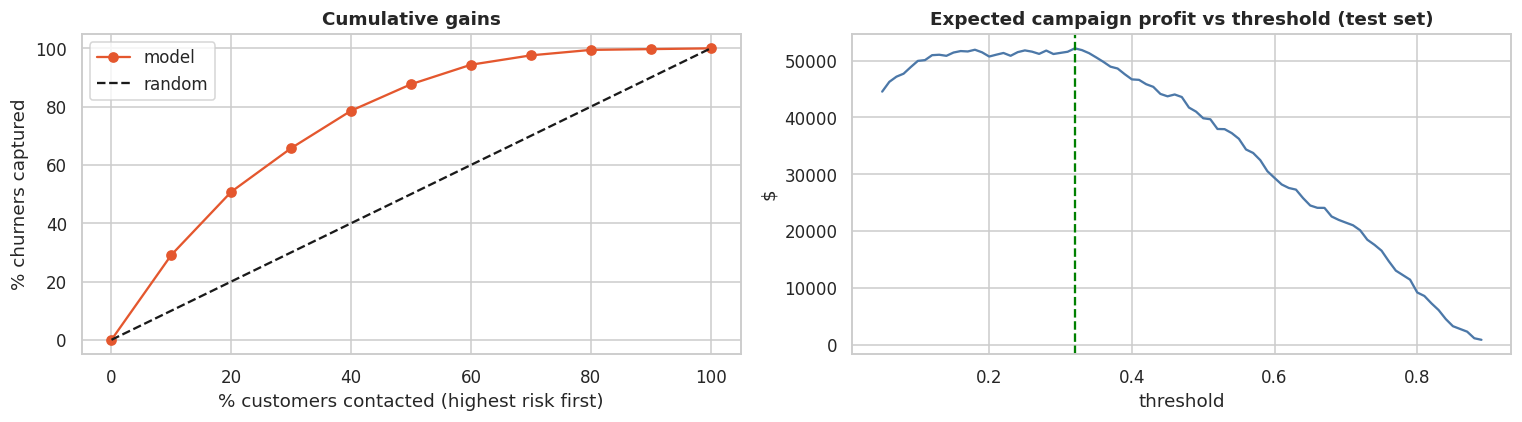

In [ ]:
# Lift / cumulative gains: what share of all churners sit in the top-k% highest-risk customers?
order = np.argsort(-p_test); cum = np.cumsum(y_test[order]) / y_test.sum()
pct = np.arange(10, 101, 10); gains = [float(cum[int(len(y_test) * q / 100) - 1]) for q in pct]
gt = pd.DataFrame({"contacted %": pct, "churners captured %": np.round(np.array(gains) * 100, 1), "lift": np.round(np.array(gains) / (pct / 100), 2)}); display(gt.T)

# Illustrative campaign economics (edit the assumptions to match the business)
OFFER_COST, SAVE_RATE, HORIZON = 50, 0.30, 12      # $ per contacted customer, share of at-risk churners retained, months of revenue protected
mc = X_test["MonthlyCharges"].values
def campaign_profit(flag): return float((flag * (y_test == 1) * SAVE_RATE * mc * HORIZON).sum() - OFFER_COST * flag.sum())
ts = np.arange(0.05, 0.9, 0.01); prof = [campaign_profit((p_test >= t).astype(int)) for t in ts]
t_star = ts[int(np.argmax(prof))]
print(f"Assumptions: ${OFFER_COST} offer, {SAVE_RATE:.0%} of contacted churners saved, {HORIZON} months of revenue protected")
print(f"Contact nobody: $0 | Contact everyone: ${campaign_profit(np.ones(len(y_test), int)):,.0f} | Model @ F1 threshold {thr_f1:.2f}: ${campaign_profit((p_test >= thr_f1).astype(int)):,.0f} | profit-optimal threshold {t_star:.2f}: ${max(prof):,.0f}")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot([0] + list(pct), [0] + list(np.array(gains) * 100), "o-", color=RED, label="model"); ax[0].plot([0, 100], [0, 100], "k--", label="random"); ax[0].set(title="Cumulative gains", xlabel="% customers contacted (highest risk first)", ylabel="% churners captured"); ax[0].legend()
ax[1].plot(ts, prof, color=BLUE); ax[1].axvline(t_star, ls="--", color="green"); ax[1].set(title="Expected campaign profit vs threshold (test set)", xlabel="threshold", ylabel="$"); plt.tight_layout(); plt.show()

## 11. Export the model for the React dashboard

In [ ]:
BIAS_CAL = float(final.b_ + np.log(pi / (1 - pi)))                 # prior-corrected intercept -> calibrated probabilities
NICE = {"SeniorCitizen": "Senior citizen", "tenure": "Tenure (months)", "MonthlyCharges": "Monthly charges", "n_addons": "Number of add-ons", "tenure_log": "Tenure (log)",
        "autopay": "Automatic payment", "mtm_fiber": "Month-to-month + Fiber", "mtm_echeck": "Month-to-month + e-check", "family": "Has partner/dependents", "no_support_internet": "Internet without security/support"}
specs = []
for f in X_all.columns:
    if f in NUM_COLS: specs.append(dict(name=f, label=NICE[f], type="num", key=f))
    else:
        c = next(c for c in CAT_COLS if f.startswith(c + "_")); lv = f[len(c) + 1:]
        specs.append(dict(name=f, label=f"{c}: {lv}", type="cat", key=c, level=lv))

# Parity samples: raw customers + Python probability, so the JS port can be verified numerically
idx = list(X_test.index[:12]) + list(X_test.index[np.argsort(-p_test)[:4]]) + list(X_test.index[np.argsort(p_test)[:4]])
pos = [X_test.index.get_loc(i) for i in idx]
keep_cols = [c for c in raw.columns if c not in ["customerID", "gender", "TotalCharges", "Churn"]]
samples = [dict(raw=raw.loc[i, keep_cols].to_dict(), prob=float(p_test[j])) for i, j in zip(idx, pos)]

def seg(col, d=df): return [dict(name=str(k), rate=float(g.Churn.mean()), n=int(len(g))) for k, g in d.groupby(col)]
tb = engineer_features(df).filter(like="tenure_bin"); dseg = df.assign(tenure_bin=pd.cut(df.tenure, [-1, 6, 12, 24, 48, 1000], labels=["0-6", "7-12", "13-24", "25-48", "49+"]))
r_f1 = metrics_at(y_test, p_test, thr_f1); fpr, tpr = roc_curve_scratch(y_test, p_test); k = np.unique(np.linspace(0, len(fpr) - 1, 90).astype(int))
export = dict(
    meta=dict(model="Logistic Regression (NumPy, from scratch)", n_customers=len(df), churn_rate=float(y_all.mean()), n_train=len(y_train), n_test=len(y_test),
              threshold=thr_f1, threshold_accuracy=thr_acc, l2=float(best_l2), n_features=len(specs)),
    features=specs, mean=mu.tolist(), std=sd.tolist(), weights=final.w_.tolist(), bias=BIAS_CAL,
    metrics=dict(operating_points={n: {**{k_: metrics_at(y_test, p_test, t)[k_] for k_ in ["accuracy", "precision", "recall", "f1"]}, "threshold": t} for n, t in points.items()},
                 roc_auc=roc_auc_scratch(y_test, p_test), ci={k_: list(map(float, v)) for k_, v in ci.items()}),
    confusion=dict(tn=r_f1["tn"], fp=r_f1["fp"], fn=r_f1["fn"], tp=r_f1["tp"]),
    roc=dict(fpr=fpr[k].round(4).tolist(), tpr=tpr[k].round(4).tolist()),
    benchmark=bench.reset_index().round(4).to_dict("records"),
    segments={c: seg(c, dseg) for c in ["Contract", "InternetService", "PaymentMethod", "tenure_bin"]},
    gains=[dict(pct=int(a), captured=float(b)) for a, b in zip(pct, gains)],
    samples=samples)
os.makedirs("../dashboard/src", exist_ok=True); os.makedirs("../models", exist_ok=True)
for path in ["../dashboard/src/model.json", "../models/churn_logreg_scratch.json"]:
    with open(path, "w") as fh: json.dump(export, fh, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print("Saved model + dashboard data ->", "../dashboard/src/model.json", "and ../models/churn_logreg_scratch.json")

Saved model + dashboard data -> ../dashboard/src/model.json and ../models/churn_logreg_scratch.json


## 12. Final report

In [ ]:
o = export["metrics"]["operating_points"]; a, f = o["Accuracy-oriented"], o["Recall-oriented (F1-tuned)"]; b = bench
display(Markdown(f"""
### Results (held-out test set, n = {len(y_test):,})

| Operating point | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| Accuracy-oriented | {a['threshold']:.2f} | **{a['accuracy']:.1%}** | {a['precision']:.1%} | {a['recall']:.1%} | {a['f1']:.3f} | {export['metrics']['roc_auc']:.3f} |
| Recall-oriented (used in dashboard) | {f['threshold']:.2f} | {f['accuracy']:.1%} | {f['precision']:.1%} | **{f['recall']:.1%}** | **{f['f1']:.3f}** | {export['metrics']['roc_auc']:.3f} |

95 % bootstrap CI for ROC-AUC: [{ci['roc_auc'][0]:.3f}, {ci['roc_auc'][1]:.3f}] · for accuracy at the F1 threshold: [{ci['accuracy'][0]:.3f}, {ci['accuracy'][1]:.3f}].

### Key insights
1. **Contract, tenure and internet/payment type drive churn.** Month-to-month + fiber + electronic-check customers in their first year are the highest-risk segment.
2. **Targeting the riskiest 30 % of customers captures {gains[2]*100:.0f} % of all churners** ({gains[2]/0.3:.1f}× lift over random contact).
3. **The from-scratch model matches scikit-learn** (coefficients agree to ~1e-5) and is on par with random forest and gradient boosting – complexity buys nothing here, so the simple, explainable model is the right production choice.

### Business implications
* Offer incentives to move month-to-month customers to annual contracts and to switch e-check payers to auto-pay.
* Bundle Online Security / Tech Support for fiber customers; run onboarding programmes during the first 6 months.
* Use the recall-oriented threshold for broad low-cost outreach and the accuracy-oriented threshold when each contact is expensive.

### A note on the accuracy ceiling
On this public dataset, ~80 % accuracy and ~0.85 ROC-AUC are the practical limit: logistic regression, random forests and gradient boosting all converge to the same values after careful feature engineering and tuning. Reported accuracies of 95 %+ for this dataset usually come from (a) measuring on training data, (b) tuning or resampling (e.g. SMOTE) before the train/test split, or (c) leaking the target into features. None of these is done here; every number above is out-of-sample.
"""))


### Results (held-out test set, n = 1,409)

| Operating point | Threshold | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| Accuracy-oriented | 0.51 | **80.6%** | 67.2% | 52.1% | 0.587 | 0.848 |
| Recall-oriented (used in dashboard) | 0.34 | 77.9% | 56.5% | **73.5%** | **0.639** | 0.848 |

95 % bootstrap CI for ROC-AUC: [0.827, 0.869] · for accuracy at the F1 threshold: [0.757, 0.800].

### Key insights
1. **Contract, tenure and internet/payment type drive churn.** Month-to-month + fiber + electronic-check customers in their first year are the highest-risk segment.
2. **Targeting the riskiest 30 % of customers captures 66 % of all churners** (2.2× lift over random contact).
3. **The from-scratch model matches scikit-learn** (coefficients agree to ~1e-5) and is on par with random forest and gradient boosting – complexity buys nothing here, so the simple, explainable model is the right production choice.

### Business implications
* Offer incentives to move month-to-month customers to annual contracts and to switch e-check payers to auto-pay.
* Bundle Online Security / Tech Support for fiber customers; run onboarding programmes during the first 6 months.
* Use the recall-oriented threshold for broad low-cost outreach and the accuracy-oriented threshold when each contact is expensive.

### A note on the accuracy ceiling
On this public dataset, ~80 % accuracy and ~0.85 ROC-AUC are the practical limit: logistic regression, random forests and gradient boosting all converge to the same values after careful feature engineering and tuning. Reported accuracies of 95 %+ for this dataset usually come from (a) measuring on training data, (b) tuning or resampling (e.g. SMOTE) before the train/test split, or (c) leaking the target into features. None of these is done here; every number above is out-of-sample.
